In [34]:
# Built using pythonguides.com
# # https://pythonguides.com/pytorch-rnn/

In [35]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [36]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [37]:
# DROPOUT
# class LSTMModel(nn.Module):
#     def __init__(self, input_size, hidden_size, output_size, num_layers, dropout=0.2):
#         super(LSTMModel, self).__init__()
#         self.hidden_size = hidden_size
#         self.num_layers = num_layers
#         self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
#                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
#         self.dropout = nn.Dropout(dropout)
#         self.fc = nn.Linear(hidden_size, output_size)

#     def forward(self, x):
#         h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
#         c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
#         out, _ = self.lstm(x, (h0, c0))
#         out = self.dropout(out[:, -1, :])  # Dropout after LSTM
#         out = self.fc(out)
#         return out

In [38]:
TurbofanRNN = LSTMModel(
    input_size=24,      # your features
    hidden_size=128,     # neurons per layer
    output_size=1,      # RUL prediction
    num_layers=1            # LSTM Layers
).to(device)

In [ ]:
# function to create sequences of data from our engine dataset
sequence_length = 70        # Edit this to experiment with different sequence lengths

def create_sequences(df, sequence_length):
    X_sequences = []
    y_sequences = []
    feature_columns = df.columns[2:-1]
    
    for engine_id in df['engine'].unique():
        engine_data = df[df['engine'] == engine_id].sort_values('cycle')
        engine_features = engine_data[feature_columns].values
        engine_rul = engine_data['RUL'].values
        
        if len(engine_features) >= sequence_length:
            for i in range(len(engine_features) - sequence_length + 1):
                X_sequences.append(engine_features[i:i + sequence_length])
                y_sequences.append(engine_rul[i + sequence_length - 1])
    
    return np.array(X_sequences), np.array(y_sequences)

# Load and scale data
Training_df = pd.read_csv('Train3.csv')
Testing_df = pd.read_csv('Test3.csv')

feature_columns = Training_df.columns[2:26]
scaler = MinMaxScaler()
Training_df[feature_columns] = scaler.fit_transform(Training_df[feature_columns])
Testing_df[feature_columns] = scaler.transform(Testing_df[feature_columns])

# Create sequences
X_train, y_train = create_sequences(Training_df, sequence_length)
X_test, y_test = create_sequences(Testing_df, sequence_length)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# Convert to tensors and move to GPU (or CPU if GPU not available)
X_train = torch.FloatTensor(X_train).to(device)
y_train = torch.FloatTensor(y_train).to(device)
X_test = torch.FloatTensor(X_test).to(device)
y_test = torch.FloatTensor(y_test).to(device)


X_train shape: (44068, 70, 24)
y_train shape: (44068,)


In [40]:
# Train the RNN
from torch.utils.data import TensorDataset, DataLoader
batch_size = 32
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(TurbofanRNN.parameters(), lr=0.001)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

epochs = 50
losses = []

TurbofanRNN.train()

for epoch in range(epochs):
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        y_pred = TurbofanRNN(batch_X)
        loss = criterion(y_pred.squeeze(), batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')

print("Training complete!")


Epoch [10/50], Loss: 5549.7440
Epoch [20/50], Loss: 2850.2657
Epoch [30/50], Loss: 1712.0666
Epoch [40/50], Loss: 810.5352
Epoch [50/50], Loss: 410.3399
Training complete!


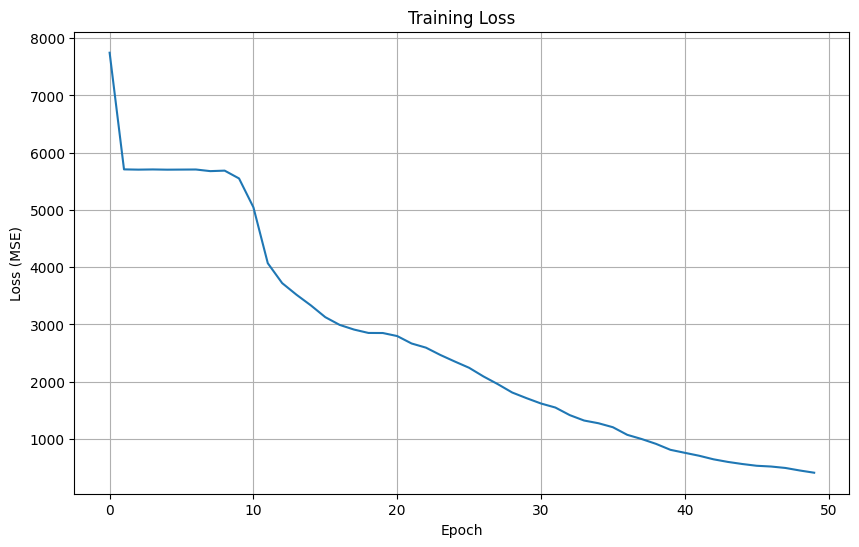

In [41]:
# Plot training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss')
plt.grid(True)
plt.show()


In [42]:
# Evaluate on test set
TurbofanRNN.eval()

# Process test set in batches to avoid OOM
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

all_predictions = []
all_targets = []
test_loss = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        y_pred = TurbofanRNN(batch_X)
        loss = criterion(y_pred.squeeze(), batch_y)
        test_loss += loss.item()
        
        all_predictions.append(y_pred.squeeze())
        all_targets.append(batch_y)

# Concatenate all batches
y_pred_test = torch.cat(all_predictions)
y_test_all = torch.cat(all_targets)

# Calculate metrics
test_loss = test_loss / len(test_loader)
mae = torch.mean(torch.abs(y_pred_test - y_test_all))
    
print(f'Test Loss (MSE): {test_loss:.4f}')
print(f'Test MAE: {mae.item():.4f}')

Test Loss (MSE): 5003.6210
Test MAE: 51.1460


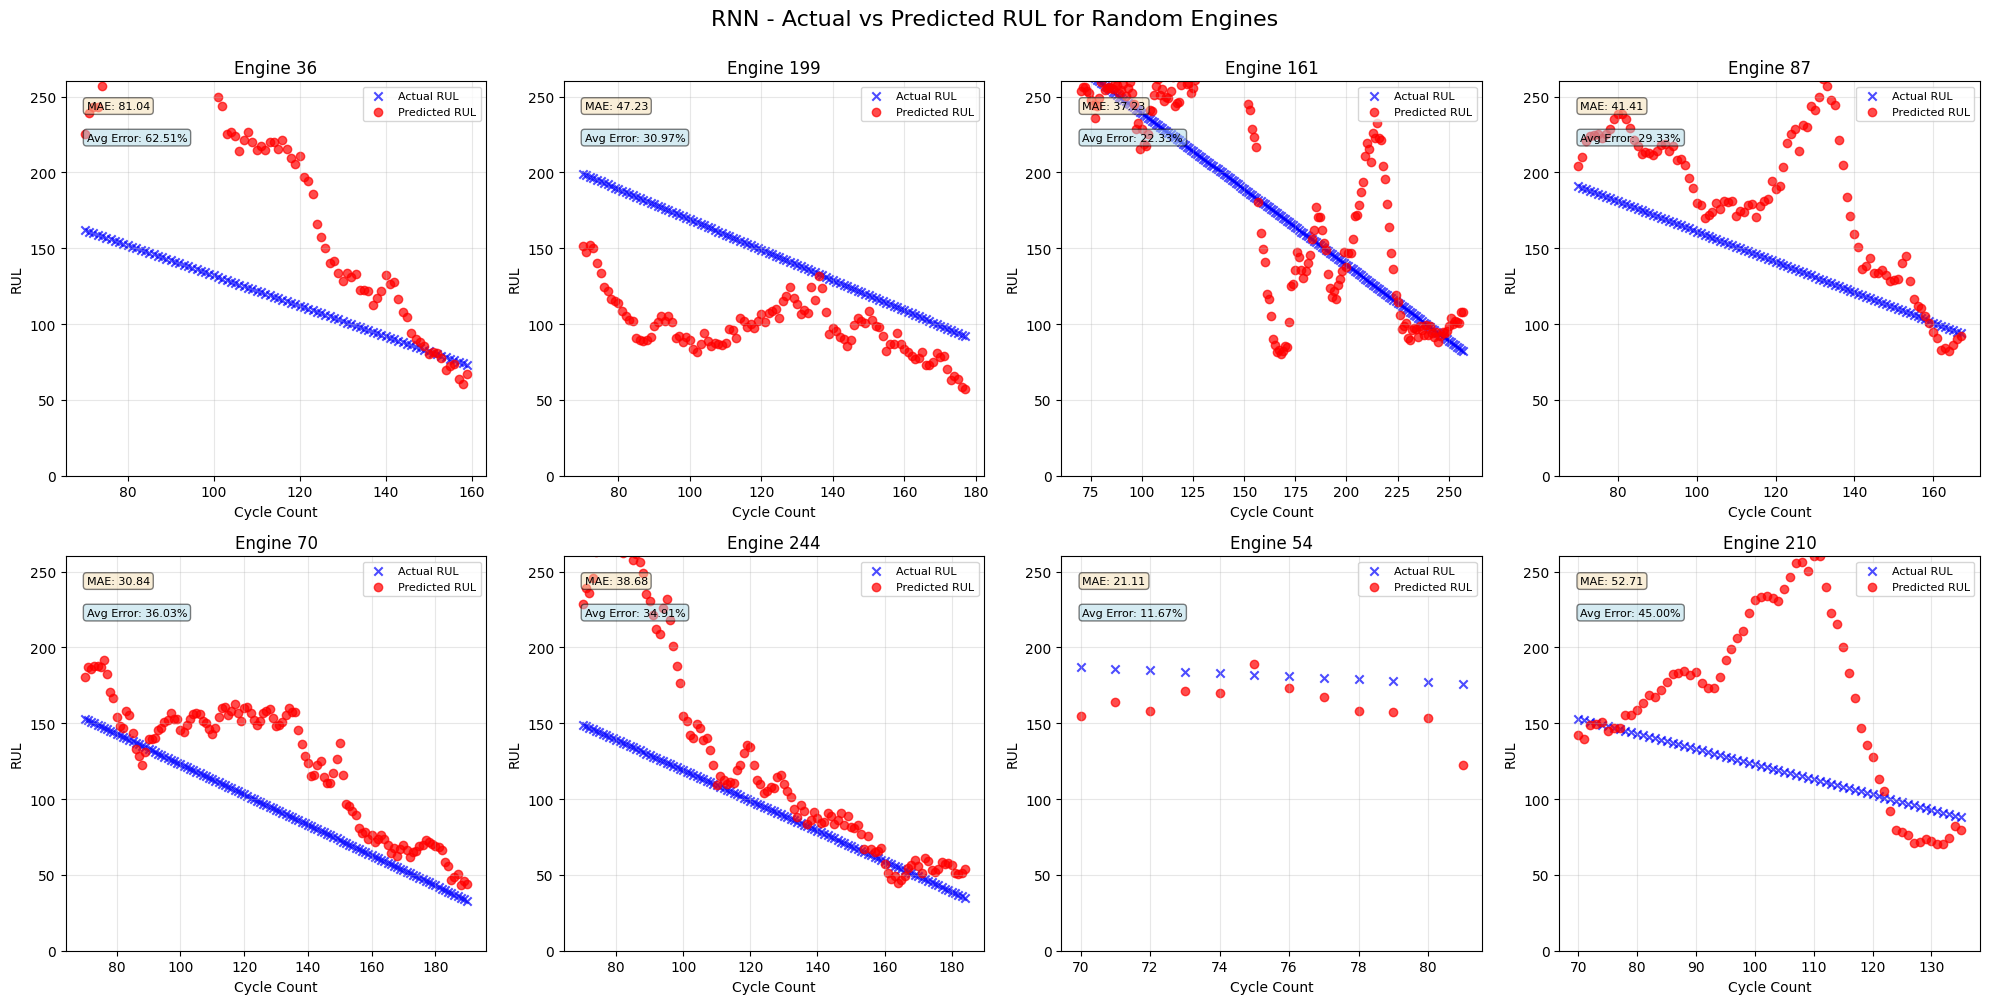

Summary Statistics for Selected Engines:
Engine 36: MAE = 81.04 cycles, Avg Error = 62.51%
Engine 199: MAE = 47.23 cycles, Avg Error = 30.97%
Engine 161: MAE = 37.23 cycles, Avg Error = 22.33%
Engine 87: MAE = 41.41 cycles, Avg Error = 29.33%
Engine 70: MAE = 30.84 cycles, Avg Error = 36.03%
Engine 244: MAE = 38.68 cycles, Avg Error = 34.91%
Engine 54: MAE = 21.11 cycles, Avg Error = 11.67%
Engine 210: MAE = 52.71 cycles, Avg Error = 45.00%


In [43]:
# Visualize predictions for individual engines
import numpy as np

TurbofanRNN.eval()
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=16, shuffle=False)
y_predictions = []

with torch.no_grad():
    for batch_X, _ in test_loader:
        y_pred = TurbofanRNN(batch_X).squeeze()
        y_predictions.append(y_pred.cpu())

y_predictions = torch.cat(y_predictions).numpy()

# We need to map predictions back to the original test dataframe
# Since we created sequences, we need to track which engine/cycle each prediction corresponds to
def get_prediction_mapping(df, sequence_length=75):
    mapping = []
    feature_columns = df.columns[2:-1]
    
    for engine_id in df['engine'].unique():
        engine_data = df[df['engine'] == engine_id].sort_values('cycle')
        
        if len(engine_data) >= sequence_length:
            for i in range(len(engine_data) - sequence_length + 1):
                # The prediction corresponds to the cycle at position i + sequence_length - 1
                cycle_idx = engine_data.index[i + sequence_length - 1]
                mapping.append(cycle_idx)
    
    return mapping

# Get the mapping of prediction indices to original dataframe indices
pred_indices = get_prediction_mapping(Testing_df, sequence_length=sequence_length)

# Create a dataframe with predictions
pred_df = Testing_df.loc[pred_indices].copy()
pred_df['predicted_RUL'] = y_predictions

# Get unique engines and randomly select 8
unique_engines = pred_df['engine'].unique()
np.random.seed(42)
selected_engines = np.random.choice(unique_engines, size=min(8, len(unique_engines)), replace=False)

# Create figure with 8 subplots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('RNN - Actual vs Predicted RUL for Random Engines', fontsize=16, y=1.00)
axes = axes.flatten()

# Plot each selected engine
for idx, engine_num in enumerate(selected_engines):
    engine_data = pred_df[pred_df['engine'] == engine_num]
    
    X_og = engine_data['cycle'].values
    Y_og = engine_data['RUL'].values
    y_pred_engine = engine_data['predicted_RUL'].values
    
    axes[idx].scatter(X_og, Y_og, label='Actual RUL', color='blue', alpha=0.7, marker='x')
    axes[idx].scatter(X_og, y_pred_engine, label='Predicted RUL', color='red', alpha=0.7)
    axes[idx].set_title(f'Engine {engine_num}')
    axes[idx].set_xlabel('Cycle Count')
    axes[idx].set_ylabel('RUL')
    axes[idx].set_ylim(0, 260)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    
    mae_engine = np.mean(np.abs(Y_og - y_pred_engine))
    errors = (Y_og - y_pred_engine) / Y_og * 100
    avg_error = np.mean(np.abs(errors))
    
    axes[idx].text(0.05, 0.95, f'MAE: {mae_engine:.2f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                   fontsize=8)
    axes[idx].text(0.05, 0.87, f'Avg Error: {avg_error:.2f}%', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5),
                   fontsize=8)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary Statistics for Selected Engines:")
print("="*60)
for engine_num in selected_engines:
    engine_data = pred_df[pred_df['engine'] == engine_num]
    Y_og = engine_data['RUL'].values
    y_pred_engine = engine_data['predicted_RUL'].values
    
    mae = np.mean(np.abs(Y_og - y_pred_engine))
    errors = (Y_og - y_pred_engine) / Y_og * 100
    avg_error = np.mean(np.abs(errors))
    print(f"Engine {engine_num}: MAE = {mae:.2f} cycles, Avg Error = {avg_error:.2f}%")

8 Engines with lowest final RUL:
  Engine 31: Final RUL = 6.0
  Engine 158: Final RUL = 6.0
  Engine 12: Final RUL = 7.0
  Engine 100: Final RUL = 7.0
  Engine 135: Final RUL = 7.0
  Engine 155: Final RUL = 7.0
  Engine 58: Final RUL = 8.0
  Engine 118: Final RUL = 8.0


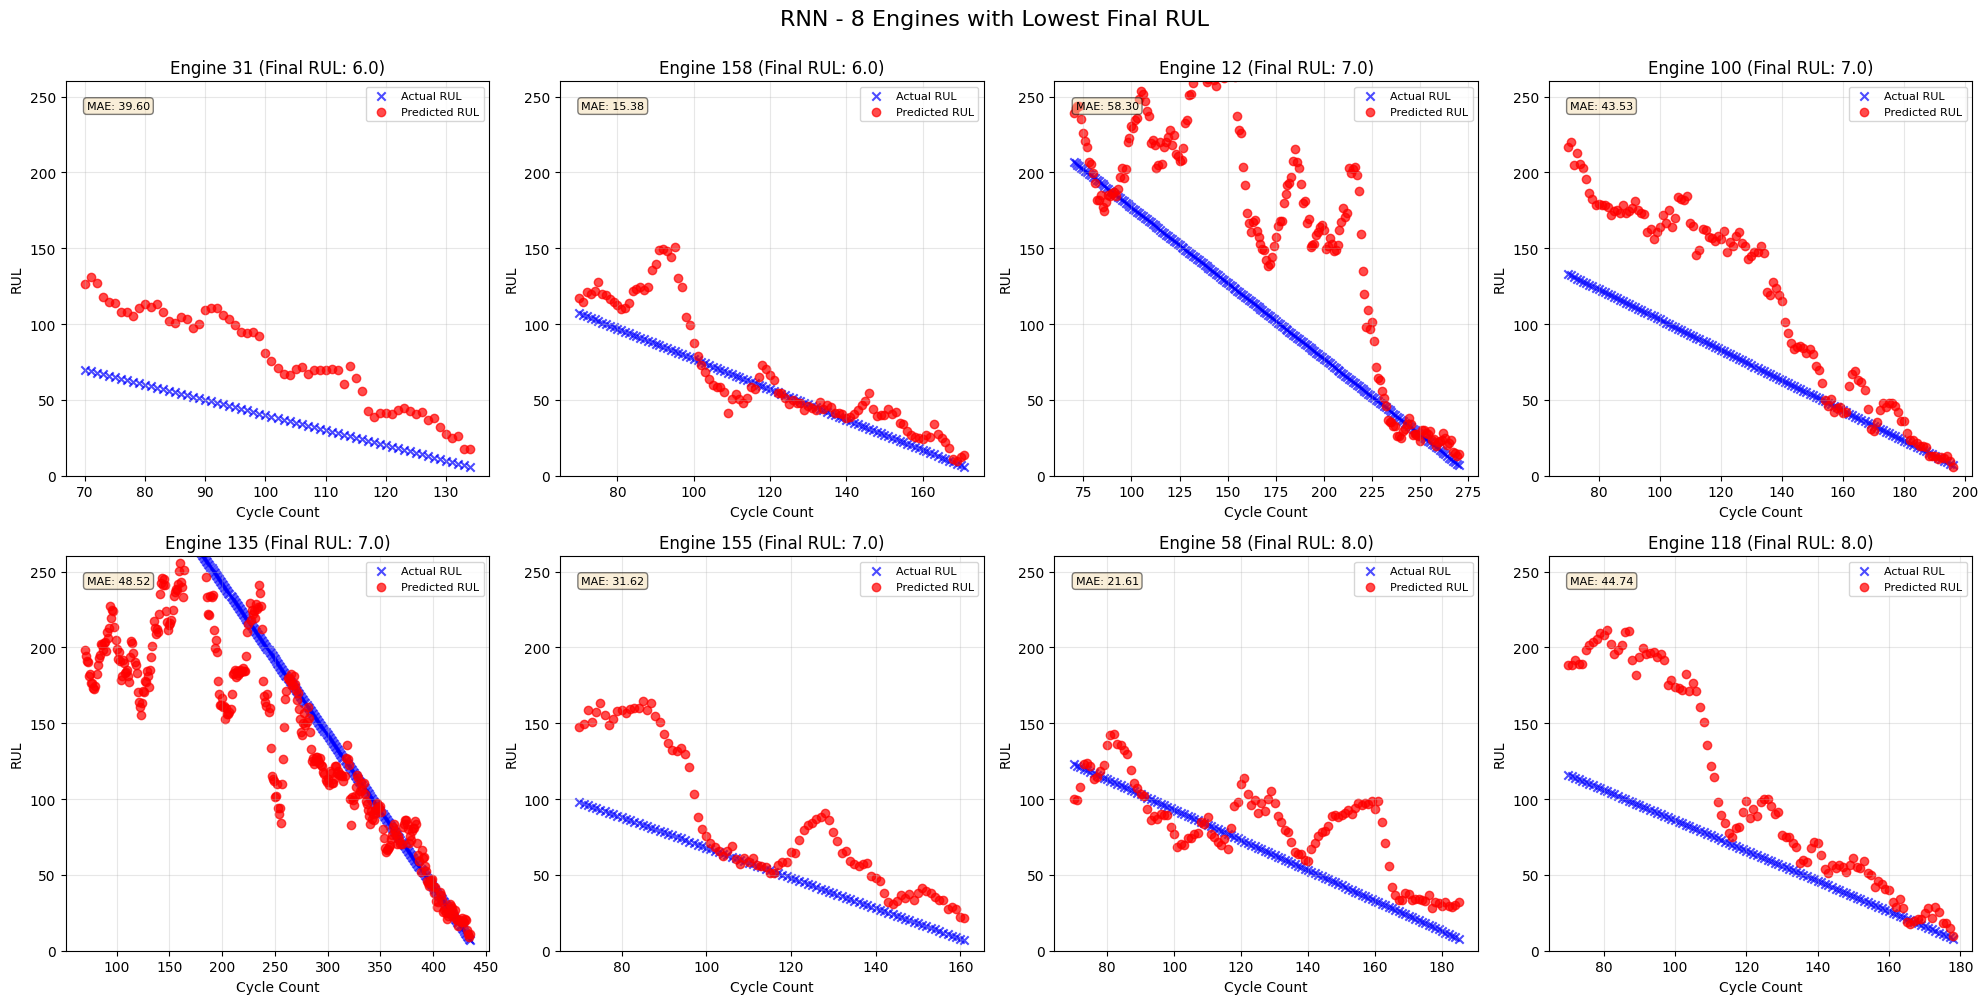


Summary Statistics for 8 Engines with Lowest Final RUL:
Engine 31 (Final RUL: 6.0): MAE = 39.60 cycles, Avg Error = 119.60%
Engine 158 (Final RUL: 6.0): MAE = 15.38 cycles, Avg Error = 33.12%
Engine 12 (Final RUL: 7.0): MAE = 58.30 cycles, Avg Error = 62.29%
Engine 100 (Final RUL: 7.0): MAE = 43.53 cycles, Avg Error = 55.54%
Engine 135 (Final RUL: 7.0): MAE = 48.52 cycles, Avg Error = 21.34%
Engine 155 (Final RUL: 7.0): MAE = 31.62 cycles, Avg Error = 71.20%
Engine 58 (Final RUL: 8.0): MAE = 21.61 cycles, Avg Error = 55.92%
Engine 118 (Final RUL: 8.0): MAE = 44.74 cycles, Avg Error = 63.41%


In [44]:
# Generate predictions for engines with the 8 lowest final RUL values
TurbofanRNN.eval()
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=16, shuffle=False)
y_predictions = []

with torch.no_grad():
    for batch_X, _ in test_loader:
        y_pred = TurbofanRNN(batch_X).squeeze()
        y_predictions.append(y_pred.cpu())

y_predictions = torch.cat(y_predictions).numpy()

# Get the mapping of prediction indices to original dataframe indices
pred_indices = get_prediction_mapping(Testing_df, sequence_length=sequence_length)

# Create a dataframe with predictions
pred_df = Testing_df.loc[pred_indices].copy()
pred_df['predicted_RUL'] = y_predictions

# Get final RUL for each engine and sort to find the 8 lowest
engine_final_rul = []
for engine_num in Testing_df['engine'].unique():
    engine_data = Testing_df[Testing_df['engine'] == engine_num]
    last_rul = engine_data['RUL'].iloc[-1]  # Get the last RUL value
    engine_final_rul.append((engine_num, last_rul))

# Sort by final RUL (ascending) and select the 8 engines with lowest final RUL
engine_final_rul.sort(key=lambda x: x[1])
selected_engines = [engine_num for engine_num, _ in engine_final_rul[:8]]

print(f"8 Engines with lowest final RUL:")
for engine_num, final_rul in engine_final_rul[:8]:
    print(f"  Engine {engine_num}: Final RUL = {final_rul:.1f}")

# Create a figure with 8 subplots (2 rows x 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('RNN - 8 Engines with Lowest Final RUL', fontsize=16, y=1.00)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot each selected engine
for idx, engine_num in enumerate(selected_engines):
    # Filter for current engine
    engine_data = pred_df[pred_df['engine'] == engine_num]
    
    # Extract cycle data and RUL values
    X_og = engine_data['cycle'].values
    Y_og = engine_data['RUL'].values
    
    # Get predictions for current engine
    y_pred_engine = engine_data['predicted_RUL'].values
    
    # Get final RUL value
    final_rul = Y_og[-1] if len(Y_og) > 0 else 0
    
    # Plot on the corresponding subplot
    axes[idx].scatter(X_og, Y_og, label='Actual RUL', color='blue', alpha=0.7, marker='x')
    axes[idx].scatter(X_og, y_pred_engine, label='Predicted RUL', color='red', alpha=0.7)
    axes[idx].set_title(f'Engine {engine_num} (Final RUL: {final_rul:.1f})')
    axes[idx].set_xlabel('Cycle Count')
    axes[idx].set_ylabel('RUL')
    axes[idx].set_ylim(0, 260)  # Set y-axis limits from 0 to 260
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    
    # Calculate and display MAE for this engine
    mae_engine = np.mean(np.abs(Y_og - y_pred_engine))
    axes[idx].text(0.05, 0.95, f'MAE: {mae_engine:.2f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                   fontsize=8)

plt.tight_layout()
plt.show()

# Print summary statistics for all selected engines
print("\nSummary Statistics for 8 Engines with Lowest Final RUL:")
print("="*60)
for engine_num in selected_engines:
    engine_data = pred_df[pred_df['engine'] == engine_num]
    Y_og = engine_data['RUL'].values
    y_pred_engine = engine_data['predicted_RUL'].values
    final_rul = Y_og[-1] if len(Y_og) > 0 else 0
    
    mae = np.mean(np.abs(Y_og - y_pred_engine))
    errors = (Y_og - y_pred_engine) / Y_og * 100
    avg_error = np.mean(np.abs(errors))
    
    print(f"Engine {engine_num} (Final RUL: {final_rul:.1f}): MAE = {mae:.2f} cycles, Avg Error = {avg_error:.2f}%")